# 활성화 함수 비교 

In [103]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

In [104]:
print("GPU 사용 가능 여부:", torch.cuda.is_available())
print("사용 가능한 GPU 개수:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("현재 GPU 이름:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPU 사용 가능 여부: True
사용 가능한 GPU 개수: 1
현재 GPU 이름: NVIDIA GeForce RTX 4070 Ti


In [105]:
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"학습 데이터 크기: {len(X_train)}")
print(f"테스트 데이터 크기: {len(X_test)}")
print(f"입력 데이터 차원: {X_train.shape[1]}")

학습 데이터 크기: 800
테스트 데이터 크기: 200
입력 데이터 차원: 2


## 모델 정의


In [106]:
class BaselineNet_relu(nn.Module):
    def __init__(self, input_size=2, num_classes=2):
        super(BaselineNet_relu, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(32, num_classes)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        logits = self.fc3(x)
        return logits
    
class BaselineNet_leaky_relu(nn.Module):
    def __init__(self, input_size=2, num_classes=2):
        super(BaselineNet_leaky_relu, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.leaky_relu1 = nn.LeakyReLU()
        self.fc2 = nn.Linear(64, 32)
        self.leaky_relu2 = nn.LeakyReLU()
        self.fc3 = nn.Linear(32, num_classes)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.leaky_relu1(x)
        x = self.fc2(x)
        x = self.leaky_relu2(x)
        logits = self.fc3(x)
        return logits
    
class BaselineNet_sigmoid(nn.Module):
    def __init__(self, input_size=2, num_classes=2):
        super(BaselineNet_sigmoid, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.sigmoid1 = nn.Sigmoid()
        self.fc2 = nn.Linear(64, 32)
        self.sigmoid2 = nn.Sigmoid()
        self.fc3 = nn.Linear(32, num_classes)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.sigmoid1(x)
        x = self.fc2(x)
        x = self.sigmoid2(x)
        logits = self.fc3(x)
        return logits

In [107]:
class ShallowNet_relu(nn.Module):
    def __init__(self, input_size=2, num_classes=2):
        super(ShallowNet_relu, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(32, num_classes)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        logits = self.fc2(x)
        return logits

class ShallowNet_leaky_relu(nn.Module):
    def __init__(self, input_size=2, num_classes=2):
        super(ShallowNet_leaky_relu, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.leaky_relu1 = nn.LeakyReLU()
        self.fc2 = nn.Linear(32, num_classes)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.leaky_relu1(x)
        logits = self.fc2(x)
        return logits

class ShallowNet_sigmoid(nn.Module):
    def __init__(self, input_size=2, num_classes=2):
        super(ShallowNet_sigmoid, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.sigmoid1 = nn.Sigmoid()
        self.fc2 = nn.Linear(32, num_classes)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.sigmoid1(x)
        logits = self.fc2(x)
        return logits

In [108]:
class DeepNet_relu(nn.Module):
    def __init__(self, input_size=2, num_classes=2):
        super(DeepNet_relu, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 32)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(32, num_classes)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        logits = self.fc4(x)
        return logits

class DeepNet_leaky_relu(nn.Module):
    def __init__(self, input_size=2, num_classes=2):
        super(DeepNet_leaky_relu, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.leaky_relu1 = nn.LeakyReLU()
        self.fc2 = nn.Linear(128, 64)
        self.leaky_relu2 = nn.LeakyReLU()
        self.fc3 = nn.Linear(64, 32)
        self.leaky_relu3 = nn.LeakyReLU()
        self.fc4 = nn.Linear(32, num_classes)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.leaky_relu1(x)
        x = self.fc2(x)
        x = self.leaky_relu2(x)
        x = self.fc3(x)
        x = self.leaky_relu3(x)
        logits = self.fc4(x)
        return logits
    
class DeepNet_sigmoid(nn.Module):
    def __init__(self, input_size=2, num_classes=2):
        super(DeepNet_sigmoid, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.sigmoid1 = nn.Sigmoid()
        self.fc2 = nn.Linear(128, 64)
        self.sigmoid2 = nn.Sigmoid()
        self.fc3 = nn.Linear(64, 32)
        self.sigmoid3 = nn.Sigmoid()
        self.fc4 = nn.Linear(32, num_classes)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.sigmoid1(x)
        x = self.fc2(x)
        x = self.sigmoid2(x)
        x = self.fc3(x)
        x = self.sigmoid3(x)
        logits = self.fc4(x)
        return logits

## 하이퍼 파라미터 및 결과 저장 구조

In [109]:
# BaselineNet_relu, BaselineNet_leaky_relu, BaselineNet_sigmoid
# ShallowNet_relu, ShallowNet_leaky_relu, ShallowNet_sigmoid
# DeepNet_relu, DeepNet_leaky_relu, DeepNet_sigmoid

config = {
    "model_type": "BaselineNet_relu",    
    "epochs": 400,                     # make_moons 200 ~ 500
    "batch_size": 32,                 # 배치 크기
    "learning_rate": 0.001,           # 학습률
    "loss_type": "CE",                # 손실 함수 (CrossEntropy)
    "optimizer_type": "Adam",         # 최적화 알고리즘: "SGD", "Momentum", "Adam"
    "momentum": 0.9,
}

In [110]:


results = {
    "config": config.copy(),

    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    
    "final_accuracy": 0.0,           
    "converged_epoch": 0,            
    
    "logits_distribution": {        
        "early": None,               
        "mid": None,                  
        "late": None                  
    },
    "gradient_flow": {                
        "early": {},
        "mid": {},
        "late": {}
    },

    "layer_outputs": {
        "early": {},  
        "mid": {},
        "late": {}
    },

    "dead_relu_ratio": {
        "early": {}, 
        "mid": {},
        "late": {}
    },
    
    "final_dead_ratio": 0.0,

}

## 학습 준비 및 실행

In [111]:
# BaselineNet_relu, BaselineNet_leaky_relu, BaselineNet_sigmoid
# ShallowNet_relu, ShallowNet_leaky_relu, ShallowNet_sigmoid
# DeepNet_relu, DeepNet_leaky_relu, DeepNet_sigmoid

if config["model_type"] == "BaselineNet_relu":
    model = BaselineNet_relu().to(device)
elif config["model_type"] == "ShallowNet_relu":
    model = ShallowNet_relu().to(device)
elif config["model_type"] == "DeepNet_relu":
    model = DeepNet_relu().to(device)
elif config["model_type"] == "ShallowNet_leaky_relu":
    model = ShallowNet_leaky_relu().to(device)
elif config["model_type"] == "BaselineNet_leaky_relu":
    model = BaselineNet_leaky_relu().to(device)
elif config["model_type"] == "DeepNet_leaky_relu":
    model = DeepNet_leaky_relu().to(device)
elif config["model_type"] == "ShallowNet_sigmoid":
    model = ShallowNet_sigmoid().to(device)  
elif config["model_type"] == "BaselineNet_sigmoid":
    model = BaselineNet_sigmoid().to(device)  
elif config["model_type"] == "DeepNet_sigmoid":
    model = DeepNet_sigmoid().to(device)    


if config["optimizer_type"] == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])
elif config["optimizer_type"] == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=config["learning_rate"])    
elif config["optimizer_type"] == "Momentum":
    optimizer = optim.SGD(model.parameters(), lr=config["learning_rate"], momentum=config["momentum"])

scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
activation_outputs  = {}

def get_activation_hook(name):
    def hook(model, input, output):
        activation_outputs[name] = output.detach().cpu()
    return hook

def register_hooks(model):
    hooks = []
    for name, layer in model.named_children():
        if any(act in name.lower() for act in ["relu", "leaky", "sigmoid"]):
            h = layer.register_forward_hook(get_activation_hook(name))
            hooks.append(h)
    return hooks

def init_weights_small(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.normal_(m.weight, mean=0.0, std=0.01)
        torch.nn.init.constant_(m.bias, -0.1)

model.apply(init_weights_small)
hooks = register_hooks(model)

best_val_loss = float('inf')
epochs = config["epochs"]
check_epochs = [1, epochs // 2, epochs]
all_epoch_dead_counts = []


fc1_contribution_history = []
fc2_contribution_history = []


In [112]:
for epoch in range(1, epochs + 1):
    
    # --- [TRAIN LOOP] ---
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    epoch_first_logits = None

    epoch_dead_ratios = {}
    
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        

        optimizer.zero_grad()
        activation_outputs.clear()

        logits = model(inputs)

        if batch_idx == 0:
            epoch_first_logits = logits.detach().cpu().numpy()
            if epoch in check_epochs:

                period = "early" if epoch == check_epochs[0] else "mid" if epoch == check_epochs[1] else "late"
                
                # for layer_name, act_val in activation_outputs.items():
                #     results["layer_outputs"][period][layer_name] = act_val.numpy()
                    
                #     # 뉴런별 Dead 비율 계산 (값이 정확히 0 이하 혹은 0인 비율)
                #     # LeakyReLU나 Sigmoid는 0이 발생하지 않으므로 ReLU 검증용
                #     dead_mask = (act_val <= 0).float()
                #     neuron_dead_ratio = dead_mask.mean(dim=0).numpy() # (뉴런수,) 크기
                #     results["dead_relu_ratio"][period][layer_name] = neuron_dead_ratio

                for layer_name, act_val in activation_outputs.items():
                    results["layer_outputs"][period][layer_name] = act_val.numpy()
                    
                    # 모델 타입에 따른 분기 처리
                    if "leaky" in config["model_type"].lower():
                        # Leaky ReLU는 음수 출력이 정상적이므로, 0 이하가 아니라 
                        # 실제로 완전히 작동이 멈춘 극소값(예: 절대값이 1e-7 이하)이거나 
                        # 혹은 이 지표를 '음수 영역에 머무는 비율'로 해석해야 합니다.
                        # 여기서는 단순히 0인 비율만 찾거나, 아래처럼 0으로 둡니다.
                        neuron_dead_ratio = np.zeros(act_val.shape[1]) 
                    else:
                        # 일반 ReLU용 (정확히 0인 것만 Dead로 판정)
                        dead_mask = (act_val == 0).float()
                        neuron_dead_ratio = dead_mask.mean(dim=0).numpy()
                        
                    results["dead_relu_ratio"][period][layer_name] = neuron_dead_ratio

        criterion = nn.CrossEntropyLoss()
        loss = criterion(logits, labels)
            
        loss.backward()

        

        if batch_idx == 0 and epoch in check_epochs:
            period = "early" if epoch == check_epochs[0] else "mid" if epoch == check_epochs[1] else "late"
            for name, param in model.named_parameters():
                if param.grad is not None and "weight" in name:
                    results["gradient_flow"][period][name] = param.grad.abs().mean().item()


        optimizer.step()
        
        if "relu1" in activation_outputs:
            all_epoch_dead_counts.append((activation_outputs["relu1"] <= 0).float().mean().item())
        elif "leaky_relu1" in activation_outputs:
            all_epoch_dead_counts.append((activation_outputs["leaky_relu1"] <= 0).float().mean().item())
        else:
            all_epoch_dead_counts.append(0.0)

        # 통계 누적
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(logits, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = train_loss / total_train
    epoch_train_acc = (correct_train / total_train) * 100

    # --- [TEST LOOP] ---
    model.eval()
    test_loss, correct_test, total_test = 0.0, 0, 0
    
    with torch.no_grad():

        fc1_grad = model.fc1.weight.grad.abs().mean(dim=1).cpu().numpy() 
        fc2_grad = model.fc2.weight.grad.abs().mean(dim=1).cpu().numpy()
        
        fc1_contribution_history.append(fc1_grad)
        fc2_contribution_history.append(fc2_grad)


        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            
            loss = nn.CrossEntropyLoss()(logits, labels)
                
            test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(logits, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    epoch_test_loss = test_loss / total_test
    epoch_test_acc = (correct_test / total_test) * 100
    
    # --- [학습 결과 업데이트] ---
    results["train_loss"].append(epoch_train_loss)
    results["train_acc"].append(epoch_train_acc)
    results["val_loss"].append(epoch_test_loss)
    results["val_acc"].append(epoch_test_acc)
    
    # 최소 손실 시점(수렴 시점) 기록
    if epoch_test_loss < best_val_loss:
        best_val_loss = epoch_test_loss
        results["converged_epoch"] = epoch
        
    # 로지트 분포 기록
    if epoch == check_epochs[0]:
        results["logits_distribution"]["early"] = epoch_first_logits
    elif epoch == check_epochs[1]:
        results["logits_distribution"]["mid"] = epoch_first_logits
    elif epoch == check_epochs[2]:
        results["logits_distribution"]["late"] = epoch_first_logits

    # 스케줄러 업데이트
    scheduler.step()

    # 에폭 진행 상황 로그 출력

    print(f"Epoch [{epoch:02d}/{epochs:02d}] Train Loss: {epoch_train_loss:.4f} | Test Acc: {epoch_test_acc:.2f}%")

# 최종 실험 정확도 저장
results["final_accuracy"] = results["val_acc"][-1]
results["final_dead_ratio"] = np.mean(all_epoch_dead_counts) * 100

for h in hooks:
    h.remove()

Epoch [01/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [02/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [03/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [04/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [05/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [06/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [07/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [08/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [09/400] Train Loss: 0.6933 | Test Acc: 50.00%
Epoch [10/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [11/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [12/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [13/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [14/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [15/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [16/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [17/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [18/400] Train Loss: 0.6932 | Test Acc: 50.00%
Epoch [19/400] Train Loss: 0.6932 | Test Acc: 

## 결과 시각화

C:\Users\ynham\AppData\Local\Temp\ipykernel_15296\1560083.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(box_data, labels=box_labels, patch_artist=True,
C:\Users\ynham\AppData\Local\Temp\ipykernel_15296\1560083.py:66: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax4.set_yscale('log')


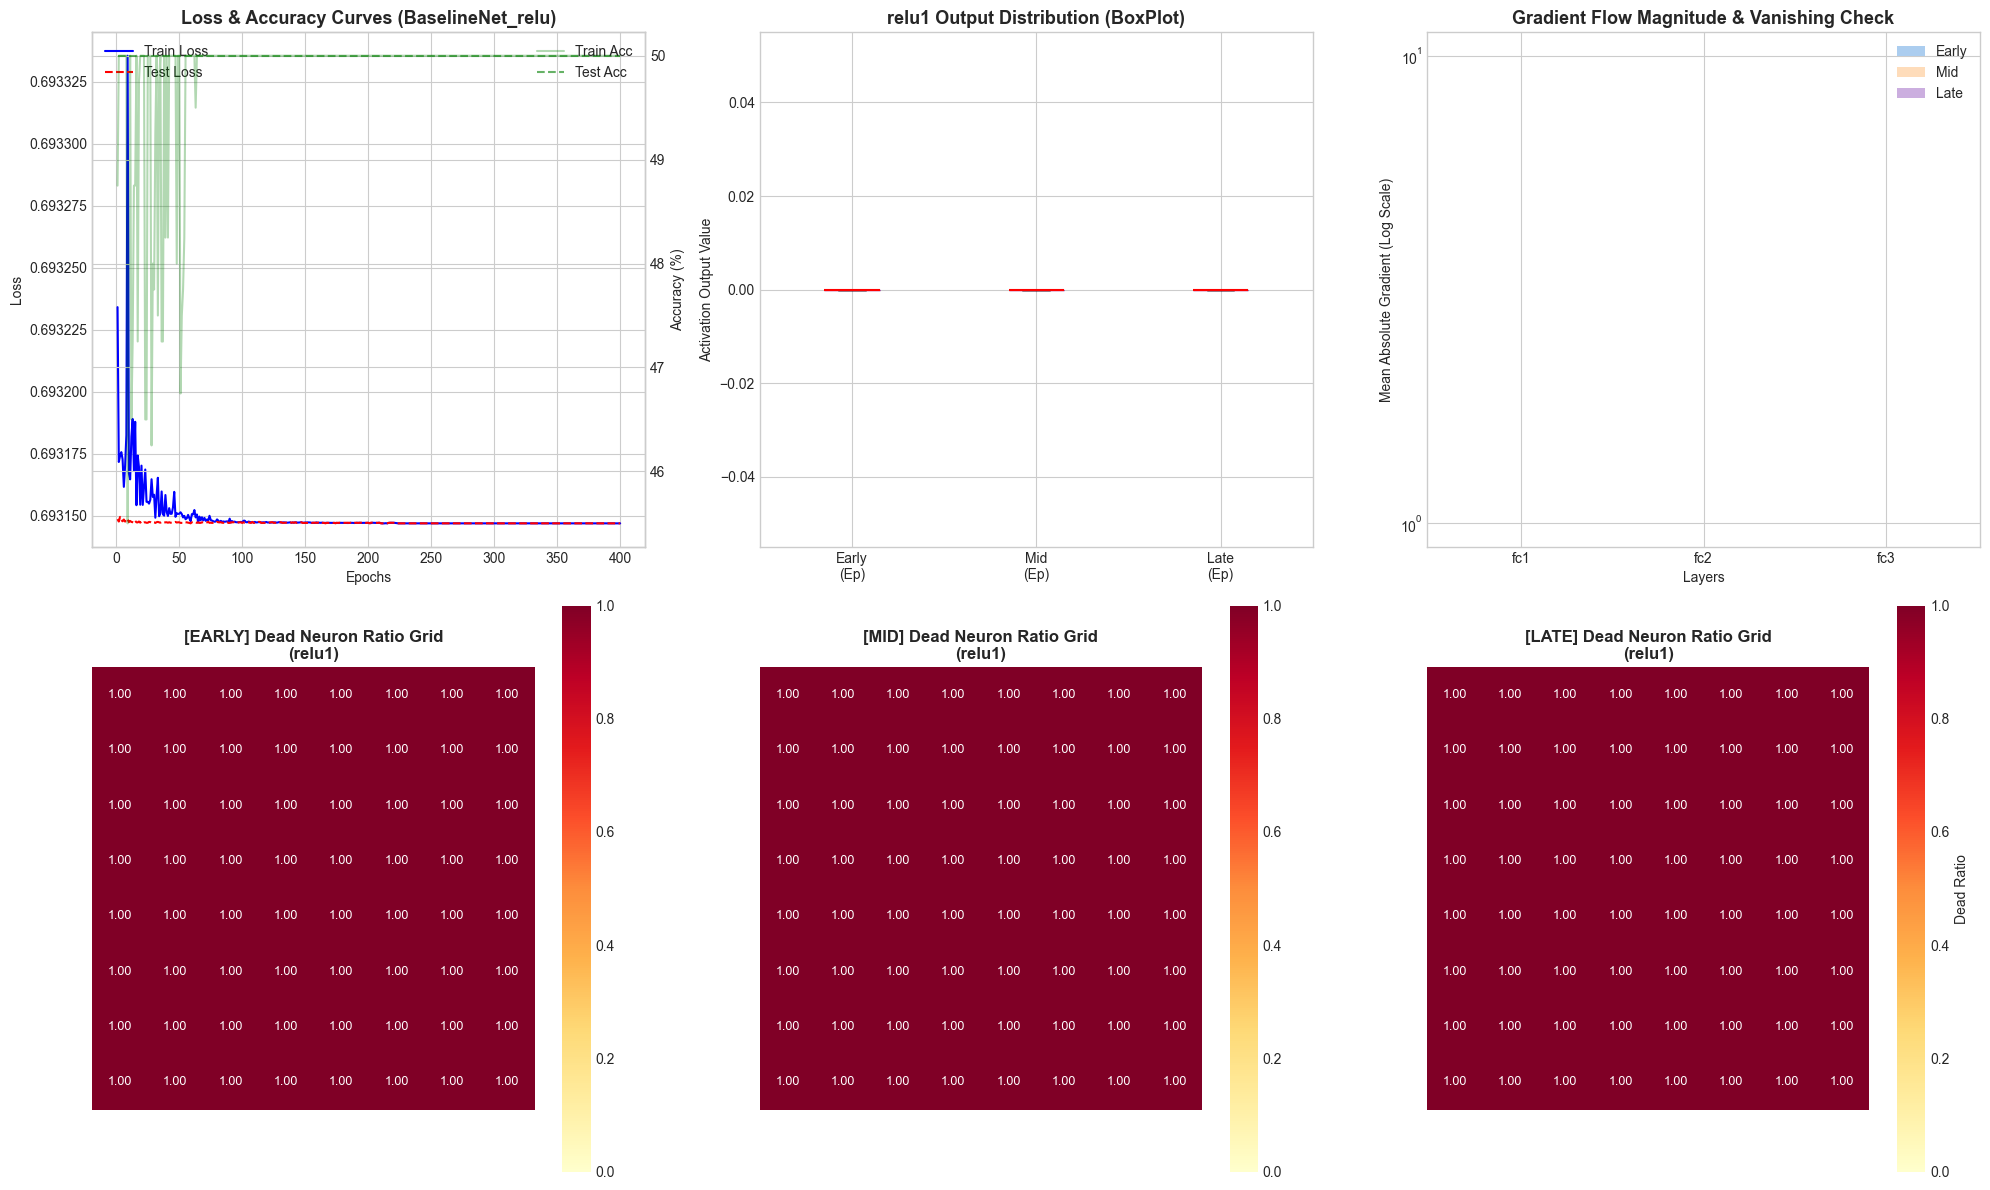


 [실험 B: 활성화 함수 비교 분석 정량 결과 요약 표]
-----------------------------------------------------------------------------------------------
 모델 타입 (활성화)            | 최종 정확도 (%)      | 수렴 속도 (최저 Loss 에폭)     | 평균 Dead 뉴런 비율 (%)   
-----------------------------------------------------------------------------------------------
 BaselineNet_relu      | 50.00          % | 59                     Epoch | 100.00              %


In [113]:
def visualize_experiment(results):
    loss_type = results["config"]["loss_type"]
    model_name = results["config"]["model_type"]
    epochs_range = range(1, len(results["train_loss"]) + 1)
    
    plt.style.use('seaborn-v0_8-whitegrid')
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12), gridspec_kw={'height_ratios': [1, 1.1]})
    

    ax1 = axes[0, 0]
    ax1.plot(epochs_range, results["train_loss"], 'b-', label='Train Loss')
    ax1.plot(epochs_range, results["val_loss"], 'r--', label='Test Loss')
    ax1.set_title(f'Loss & Accuracy Curves ({model_name})', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend(loc='upper left')
    
    ax1_twin = ax1.twinx()
    ax1_twin.plot(epochs_range, results["train_acc"], 'g-', alpha=0.3, label='Train Acc')
    ax1_twin.plot(epochs_range, results["val_acc"], 'g--', alpha=0.6, label='Test Acc')
    ax1_twin.set_ylabel('Accuracy (%)')
    ax1_twin.legend(loc='upper right')
    

    ax2 = axes[0, 1]
    periods = ["early", "mid", "late"]
    box_data = []
    box_labels = []
    
    first_layer_key = list(results["layer_outputs"]["early"].keys())[0] if results["layer_outputs"]["early"] else None
    
    if first_layer_key:
        for p in periods:
            data = results["layer_outputs"][p].get(first_layer_key)
            if data is not None:
                box_data.append(data.flatten())
                box_labels.append(f'{p.capitalize()}\n(Ep)')
        
        ax2.boxplot(box_data, labels=box_labels, patch_artist=True,
                    boxprops=dict(facecolor='#cbaedf', color='purple'),
                    medianprops=dict(color='red', linewidth=1.5))
        ax2.set_title(f'{first_layer_key} Output Distribution (BoxPlot)', fontsize=13, fontweight='bold')
        ax2.set_ylabel('Activation Output Value')
    else:
        ax2.text(0.5, 0.5, 'No Activation Data', ha='center', va='center')


    ax4 = axes[0, 2]
    layers = list(results["gradient_flow"]["early"].keys()) if results["gradient_flow"]["early"] else []
    x_indexes = np.arange(len(layers))
    bar_width = 0.25
    
    if layers:
        early_grads = [results["gradient_flow"]["early"][l] for l in layers]
        mid_grads = [results["gradient_flow"]["mid"][l] for l in layers] if results["gradient_flow"]["mid"] else [0]*len(layers)
        late_grads = [results["gradient_flow"]["late"][l] for l in layers] if results["gradient_flow"]["late"] else [0]*len(layers)
        
        ax4.bar(x_indexes - bar_width, early_grads, bar_width, label='Early', color='#abcdef')
        ax4.bar(x_indexes, mid_grads, bar_width, label='Mid', color='#fedcba')
        ax4.bar(x_indexes + bar_width, late_grads, bar_width, label='Late', color='#cbaedf')
        
        display_names = [l.split('.')[0] for l in layers]
        ax4.set_xticks(x_indexes)
        ax4.set_xticklabels(display_names)
        ax4.set_yscale('log') 
        ax4.set_title('Gradient Flow Magnitude & Vanishing Check', fontsize=13, fontweight='bold')
        ax4.set_xlabel('Layers')
        ax4.set_ylabel('Mean Absolute Gradient (Log Scale)')
        ax4.legend()
    else:
        ax4.text(0.5, 0.5, 'No Gradient Data', ha='center', va='center')


    if first_layer_key and results["dead_relu_ratio"]["early"]:
        for i, p in enumerate(periods):

            ax_heat = axes[1, i]
            
            ratio_data = results["dead_relu_ratio"][p].get(first_layer_key)
            if ratio_data is not None:
                num_neurons = len(ratio_data)
                
                side = int(np.sqrt(num_neurons))
                if side * side == num_neurons:
                    grid_data = ratio_data.reshape(side, side)
                else:
                    grid_data = ratio_data.reshape(2, -1)
                
                sns.heatmap(grid_data, cmap='YlOrRd', vmin=0, vmax=1, 
                            annot=True, fmt=".2f", annot_kws={"size": 9},
                            cbar=True, cbar_kws={'label': 'Dead Ratio'} if i == 2 else {},
                            square=True, ax=ax_heat)
                
                ax_heat.set_title(f'[{p.upper()}] Dead Neuron Ratio Grid\n({first_layer_key})', fontsize=12, fontweight='bold')
                ax_heat.set_xticks([]) 
                ax_heat.set_yticks([])
            else:
                ax_heat.text(0.5, 0.5, f'No {p} data', ha='center', va='center')
    else:
        for j in range(3):
            axes[1, j].axis('off')
        axes[1, 1].text(0.5, 0.5, 'Heatmap Not Applicable\n(This model does not produce structural dead neurons like ReLU)', 
                      ha='center', va='center', fontsize=13, color='gray', fontweight='bold')
        
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------------------
    # [5] 활성화 함수 분석 실험 전용 정량 결과 요약 표 출력 서식
    # -----------------------------------------------------------------
    print("\n" + "="*95)
    print(f" [실험 B: 활성화 함수 비교 분석 정량 결과 요약 표]")
    print("-"*95)
    print(f" {'모델 타입 (활성화)':<22} | {'최종 정확도 (%)':<15} | {'수렴 속도 (최저 Loss 에폭)':<22} | {'평균 Dead 뉴런 비율 (%)':<20}")
    print("-"*95)
    print(f" {results['config']['model_type']:<21} | {results['final_accuracy']:<15.2f}% | {results['converged_epoch']:<22} Epoch | {results['final_dead_ratio']:<20.2f}%")
    print("="*95)




visualize_experiment(results)

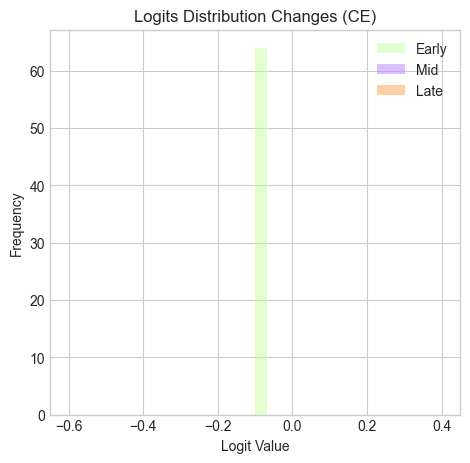

In [114]:
def visualize_experiment_b(results):
    loss_type = results["config"]["loss_type"]
    epochs = range(1, len(results["train_loss"]) + 1)
 
    plt.style.use('seaborn-v0_8-whitegrid')
    fig = plt.figure(figsize=(18, 5))


    ax2 = fig.add_subplot(1, 3, 2)
    periods = ["early", "mid", "late"]
    colors = ["#c4ffa1", "#b885ff", "#ffa34d"]
    
    for p, c in zip(periods, colors):
        data = results["logits_distribution"][p]
        if data is not None:
            ax2.hist(data.flatten(), bins=30, alpha=0.5, label=p.capitalize(), color=c)
            
    ax2.set_title(f'Logits Distribution Changes ({loss_type})')
    ax2.set_xlabel('Logit Value')
    ax2.set_ylabel('Frequency')
    ax2.legend()




visualize_experiment_b(results)

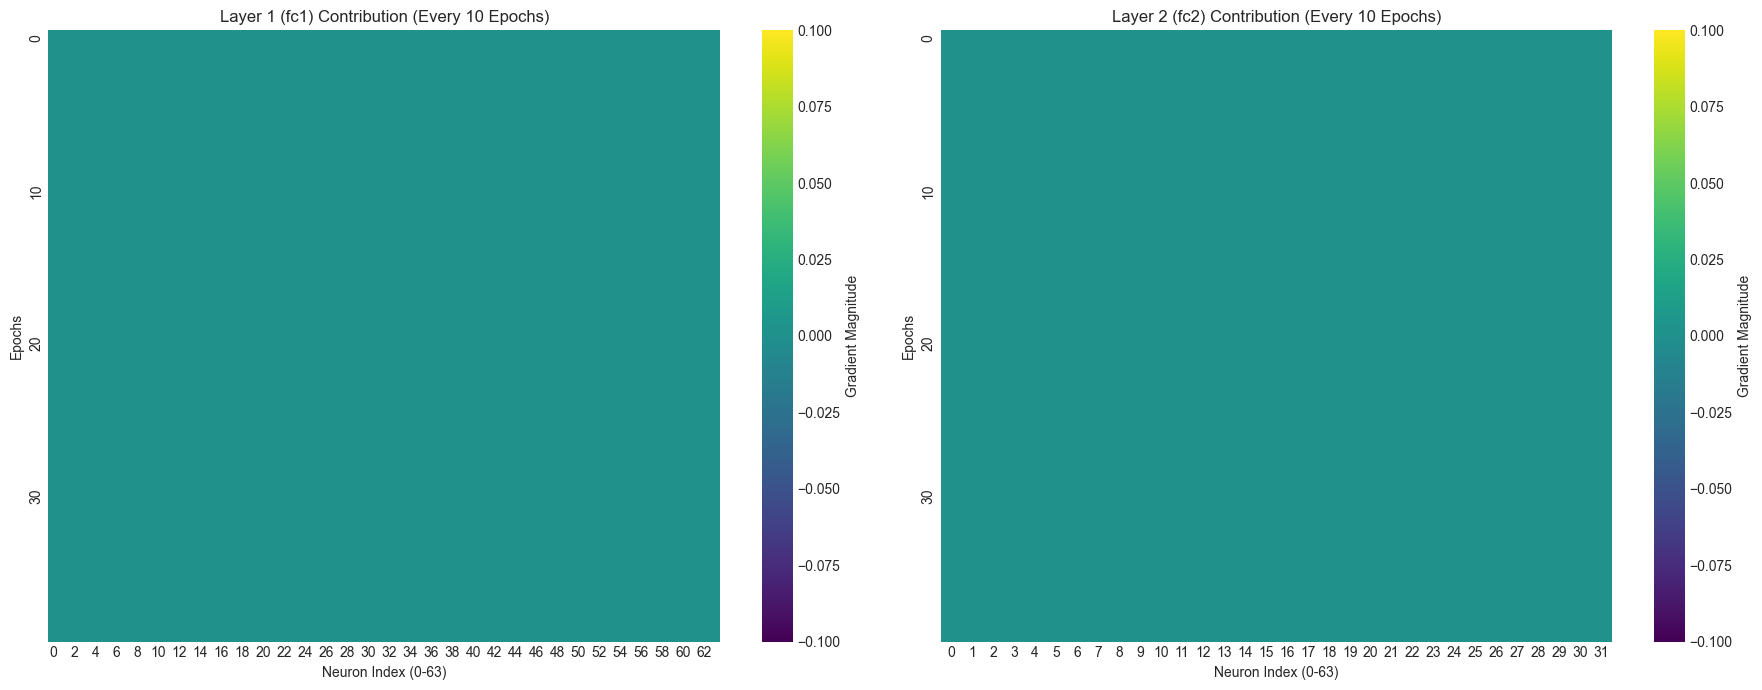

In [115]:

fc1_full_data = np.array(fc1_contribution_history) 
fc2_full_data = np.array(fc2_contribution_history)

fc1_heatmap_data = fc1_full_data[::10, :]
fc2_heatmap_data = fc2_full_data[::10, :]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))


sns.heatmap(fc1_heatmap_data, ax=axes[0], cmap='viridis', 
            yticklabels=10, cbar_kws={'label': 'Gradient Magnitude'})
axes[0].set_title('Layer 1 (fc1) Contribution (Every 10 Epochs)')
axes[0].set_xlabel('Neuron Index (0-63)')
axes[0].set_ylabel('Epochs')

sns.heatmap(fc2_heatmap_data, ax=axes[1], cmap='viridis', 
            yticklabels=10, cbar_kws={'label': 'Gradient Magnitude'})
axes[1].set_title('Layer 2 (fc2) Contribution (Every 10 Epochs)')
axes[1].set_xlabel('Neuron Index (0-63)')
axes[1].set_ylabel('Epochs')

plt.tight_layout()
plt.show()